In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

ابعاد X: (50, 30)
رتبه تقریبی X: 30


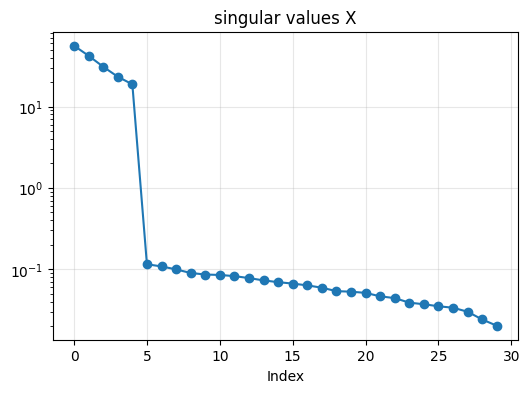

In [22]:

np.random.seed(42)
torch.manual_seed(42)

m, n = 50, 30
rank_true = 5

U = np.random.randn(m, rank_true)
V = np.random.randn(rank_true, n)
X_true = U @ V
noise = 0.01 * np.random.randn(m, n)
X = X_true + noise

print(f"ابعاد X: {X.shape}")
print(f"رتبه تقریبی X: {np.linalg.matrix_rank(X)}")

s_full = svd(X, compute_uv=False)
plt.figure(figsize=(6, 4))
plt.plot(s_full, 'o-')
plt.title('singular values X')
plt.xlabel('Index')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

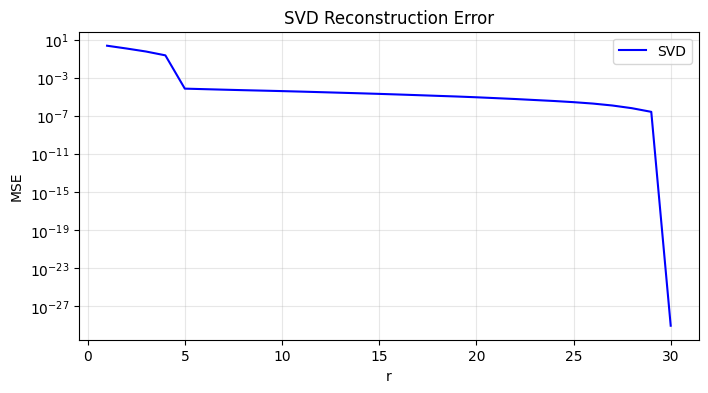

حداقل خطا (SVD): 0.000000


In [23]:
U, s, Vt = svd(X, full_matrices=False)

r_values = list(range(1, min(m, n) + 1))
svd_errors = []

for r in r_values:
    X_recon = U[:, :r] @ np.diag(s[:r]) @ Vt[:r, :]
    mse = mean_squared_error(X, X_recon)
    svd_errors.append(mse)

plt.figure(figsize=(8, 4))
plt.plot(r_values, svd_errors, 'b-', label='SVD')
plt.xlabel('r')
plt.ylabel('MSE')
plt.title('SVD Reconstruction Error')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"حداقل خطا (SVD): {svd_errors[-1]:.6f}")

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"استفاده از دستگاه: {device}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

r_test = [1, 2, 5, 10, 15, 20, 25]
ae_errors = []

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        encoded = self.relu(self.encoder(x))
        decoded = self.decoder(encoded)
        return decoded

for r in r_test:
    print(f"آموزش Autoencoder با r={r}...")
    
    model = Autoencoder(n, r).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    model.train()
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, X_tensor)
        loss.backward()
        optimizer.step()
        
        if epoch % 200 == 0:
            pass  
    
    model.eval()
    with torch.no_grad():
        X_recon_scaled = model(X_tensor).cpu().numpy()
    
    X_recon = scaler.inverse_transform(X_recon_scaled)
    mse = mean_squared_error(X, X_recon)
    ae_errors.append(mse)
    print(f"  MSE = {mse:.6f}")

استفاده از دستگاه: cpu
آموزش Autoencoder با r=1...
  MSE = 2.432534
آموزش Autoencoder با r=2...
  MSE = 2.432534
آموزش Autoencoder با r=2...
  MSE = 1.306787
آموزش Autoencoder با r=5...
  MSE = 1.306787
آموزش Autoencoder با r=5...
  MSE = 0.001312
آموزش Autoencoder با r=10...
  MSE = 0.001312
آموزش Autoencoder با r=10...
  MSE = 0.000100
آموزش Autoencoder با r=15...
  MSE = 0.000100
آموزش Autoencoder با r=15...
  MSE = 0.000100
آموزش Autoencoder با r=20...
  MSE = 0.000100
آموزش Autoencoder با r=20...
  MSE = 0.000234
آموزش Autoencoder با r=25...
  MSE = 0.000234
آموزش Autoencoder با r=25...
  MSE = 0.000182
  MSE = 0.000182


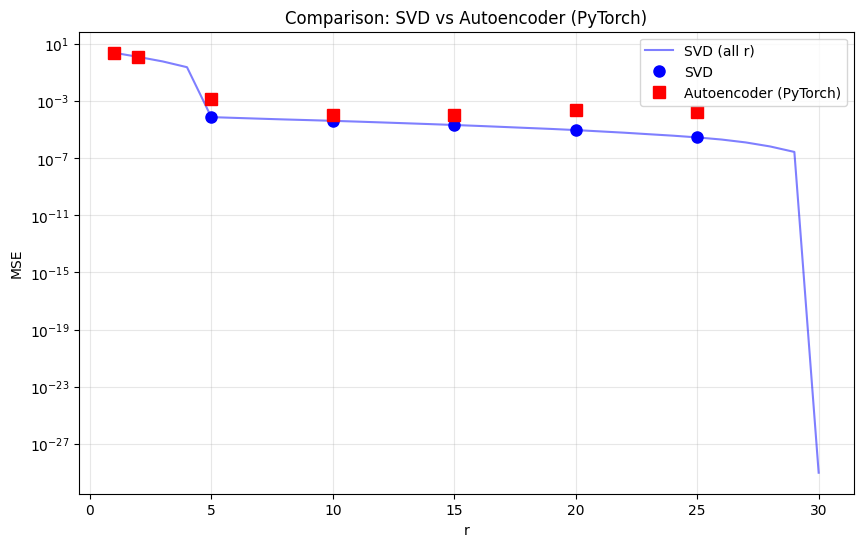

جدول مقایسه:
    r   SVD_MSE    AE_MSE
0   1  2.417050  2.432534
1   2  1.233102  1.306787
2   5  0.000075  0.001312
3  10  0.000041  0.000100
4  15  0.000021  0.000100
5  20  0.000009  0.000234
6  25  0.000003  0.000182

SVD در تمام موارد بهتر یا برابر بود.


In [25]:
svd_errors_test = [svd_errors[r-1] for r in r_test]

plt.figure(figsize=(10, 6))
plt.plot(r_values, svd_errors, 'b-', alpha=0.5, label='SVD (all r)')
plt.plot(r_test, svd_errors_test, 'bo', markersize=8, label='SVD')
plt.plot(r_test, ae_errors, 'rs', markersize=8, label='Autoencoder (PyTorch)')
plt.xlabel('r')
plt.ylabel('MSE')
plt.title('Comparison: SVD vs Autoencoder (PyTorch)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

import pandas as pd
df = pd.DataFrame({
    'r': r_test,
    'SVD_MSE': svd_errors_test,
    'AE_MSE': ae_errors
})
print("جدول مقایسه:")
print(df.round(6))

better = [r for i, r in enumerate(r_test) if ae_errors[i] < svd_errors_test[i]]
if better:
    print(f"\nAutoencoder برای r={better} بهتر عمل کرد.")
else:
    print("\nSVD در تمام موارد بهتر یا برابر بود.")